# Simulation Study

Five experiments, each isolating one claim about MoLA's archetype recovery:

1. **Archetype Recovery** — does MoLA recover the generating structure at all?
2. **Estimation Stability** — given the assumed (k-means-informed) initialization, how much does the recovered structure vary just from sampling noise in a new cohort of learners and responses? First checks a prerequisite question: does the *initialization scheme itself* matter? (Yes, for a naive uninformative start — see 2a, an exploratory check not used in the paper.)
3. **Robustness to Data Sparsity** — how gracefully does archetype recovery deteriorate as the information available for estimating the latent structure decreases (number of users, number of item responses per user)?
4. **Sensitivity to the Number of Archetypes** — what happens when the fitted number of archetypes $M$ is misspecified relative to the true generating count?
5. **Computational Scalability** — how does fit time grow with problem size?

Each needs a different axis held fixed and a different axis varied, which is why these are five separate experiments rather than one combined sweep.

Out of scope: do the learned latent variables correspond to real cognitive mastery or useful learner groups? → simulation cannot establish this; you need empirical/external validation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Allows import of modules from src/ in root
%cd ..

/Users/marialentini/Projects/mixture-of-latent-archetypes


/Users/marialentini/Projects/mixture-of-latent-archetypes/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
# Publication styling for every figure below (src/style.py): fonts/line
# weights sized for print rather than a monitor, vector-safe embedded text,
# no LaTeX toolchain dependency. figsize(...) below sizes each figure to an
# exact fraction of an ACM acmart (\documentclass[sigconf]{acmart}) column or
# text width in points -- swap the "acm-sigconf-*" keys (or pass a raw point
# value) if this paper uses a different document class; see src/style.py for
# how to read the exact number off your own compiled .log file.
from src.style import apply, figsize

apply()

## 0. Simulation Setup

Before looking at recovery, check that the simulator itself matches the intended design (`plot_setup_diagnostics`, tests the *simulator*, not MoLA): the Q-matrix's item-per-skill coverage is balanced by construction (`q_matrix`'s self-balancing weighting, replacing the old fixed-probability draw that left real sampling noise -- e.g. a 2-to-12 item range over 20 skills at typical scale), no two skills share an identical item pattern (a guaranteed check, not just unlikely by chance), the archetypes are meaningfully separated in skill space, and users land in each archetype with ordinary sampling noise around `pi` -- deliberately *not* forced to an exact proportion, since a real cohort of learners samples from the population at random rather than being recruited in stratified quotas matched to an unobserved archetype.

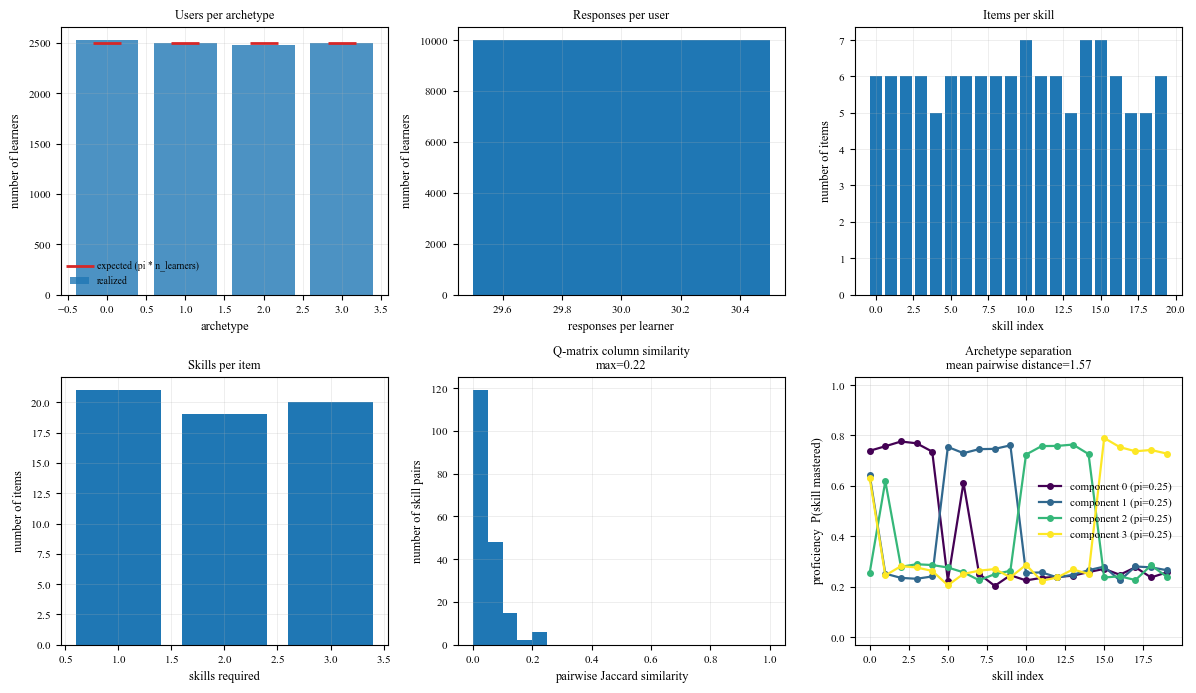

In [4]:
from src.simulations.factors import SimulationCondition
from src.simulations.dgp import generate_dataset
from src.simulations.viz import plot_setup_diagnostics

setup_data = generate_dataset(SimulationCondition(n_archetypes=4, n_learners=10_000), seed=0)
fig = plot_setup_diagnostics(setup_data, save="figures/setup_diagnostics.pdf")

## 1. Archetype Recovery

Fit MoLA on one well-specified condition and compare the recovered archetype profiles to the ones that generated the data, after Hungarian alignment. Also check item-difficulty (`theta`) recovery -- items keep a fixed, unambiguous index (no label-switching issue like archetypes have), so `plot_theta_recovery` needs no alignment step.

{'mu_rmse': 0.13159439030648015, 'theta_rmse': 0.12825691927754398, 'assignment_ari': 0.4703376944416943, 'holdout_auc': 0.7425465926370676}


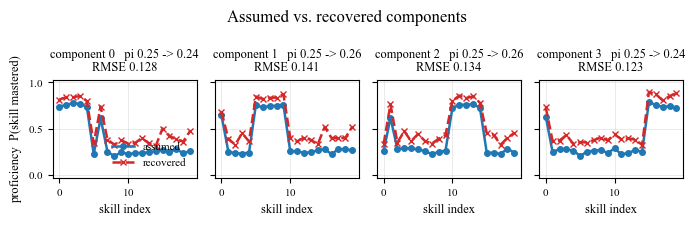

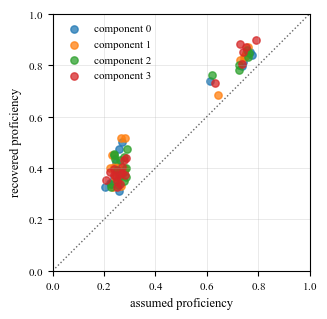

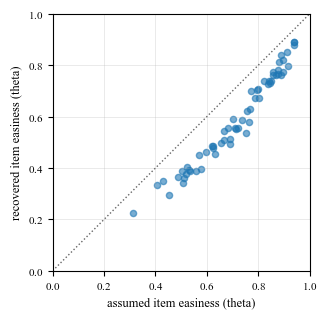

In [5]:
import matplotlib.pyplot as plt
from src.simulations import run_condition
from src.simulations.factors import SimulationCondition
from src.simulations.viz import plot_component_recovery, plot_recovery_scatter, plot_theta_recovery

result = run_condition(SimulationCondition(n_archetypes=4, n_learners=10_000), seed=0, return_fit=True)
plot_component_recovery(
    result, 
    figsize=figsize("acm-sigconf-text", aspect=0.32), 
    save="figures/component_recovery.pdf"
)

# plot_recovery_scatter / plot_theta_recovery have no figsize= of their own -- pass a pre-sized ax instead.
_, scatter_ax = plt.subplots(figsize=figsize("acm-sigconf-column", aspect=1.0))
plot_recovery_scatter(result, ax=scatter_ax, save="figures/recovery_scatter.pdf")

_, theta_ax = plt.subplots(figsize=figsize("acm-sigconf-column", aspect=1.0))
plot_theta_recovery(result, ax=theta_ax, save="figures/theta_recovery.pdf")

print({k: result.metrics[k] for k in ("mu_rmse", "theta_rmse", "assignment_ari", "holdout_auc")})

### Does EM improve on pure k-means, and where does it fall short?

`_kmeans_init` produces `mu`/`theta` estimates directly, with no EM refinement at all -- comparing its raw output (on the same data and train/holdout split used above) against MoLA's fully-fitted result shows how much the EM step actually buys, and where it can't help. EM substantially corrects k-means's `mu` recovery (naive clustering conflates item easiness and archetype mastery, since it clusters a nonlinear mixture of both), but only partially corrects `theta` -- part of both errors sits along a genuine, exact non-identifiability in the compensatory response function: `Q` is always row-normalized, so an item's log-odds of a correct response is `logit(theta_j) + q_norm_j @ logit(mu_k)`. Shifting every `mu` value down and every `theta` value up by the same constant (in logit space) leaves this, and the entire likelihood, exactly unchanged -- verified directly: fitting from the true parameters keeps EM almost exactly there, while fitting from a k-means or random start lands measurably off, and neither that bias nor pure k-means's own error shrinks with 100x more data (ruling out sampling noise as the cause).

,mu_bias,mu_rmse,theta_bias,theta_rmse
pure k-means (no EM),0.207461,0.278068,-0.103458,0.109515
"MoLA, k-means-initialized (EM-fitted)",0.123234,0.131594,-0.122359,0.128257


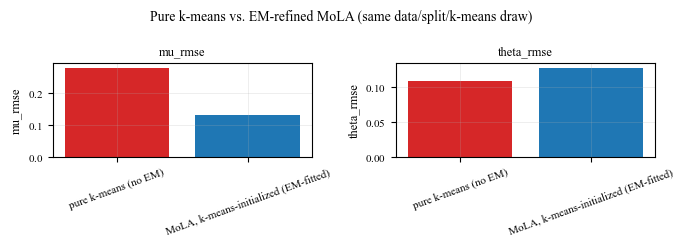

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.simulations.factors import SimulationCondition
from src.simulations.dgp import generate_dataset
from src.simulations.run import split_holdout, _kmeans_init
from src.simulations.metrics import align_components

# Same condition/data/split `result` above used (recomputed here since the
# earlier cell only kept the fitted model+metrics, not the intermediate
# k-means draw) -- same seeds, so this reproduces the exact same data, train
# split, and k-means initialization that fed that fit.
recovery_condition = SimulationCondition(n_archetypes=4, n_learners=10_000)
recovery_data = generate_dataset(recovery_condition, seed=0)
recovery_rng = np.random.default_rng(0)
X_train, _hold_mask = split_holdout(recovery_data.X, recovery_condition.holdout_frac, recovery_rng)
km_mu, km_theta, km_pi = _kmeans_init(
    X_train, recovery_data.Q_fit, recovery_condition.n_archetypes, recovery_rng
)

def _bias_and_rmse(mu_true, mu_est, theta_true, theta_est):
    k = min(mu_true.shape[1], mu_est.shape[1])
    perm = align_components(mu_true[:, :k], mu_est[:, :k])
    mu_err = mu_est[perm, :k] - mu_true[:, :k]
    theta_err = np.asarray(theta_est).ravel() - np.asarray(theta_true).ravel()
    return {
        "mu_bias": mu_err.mean(), "mu_rmse": np.sqrt((mu_err ** 2).mean()),
        "theta_bias": theta_err.mean(), "theta_rmse": np.sqrt((theta_err ** 2).mean()),
    }

comparison = pd.DataFrame({
    "pure k-means (no EM)": _bias_and_rmse(recovery_data.mu, km_mu, recovery_data.theta, km_theta),
    "MoLA, k-means-initialized (EM-fitted)": _bias_and_rmse(
        recovery_data.mu, result.model.mu, recovery_data.theta, result.model.theta
    ),
}).T[["mu_bias", "mu_rmse", "theta_bias", "theta_rmse"]]

fig, axes = plt.subplots(1, 2, figsize=figsize("acm-sigconf-text", aspect=0.35))
for ax, metric in zip(axes, ["mu_rmse", "theta_rmse"]):
    ax.bar(comparison.index, comparison[metric], color=["#d62728", "#1f77b4"])
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Pure k-means vs. EM-refined MoLA (same data/split/k-means draw)")
fig.tight_layout()

comparison

## 2. Estimation Stability

Two questions live under this heading. **2a** answers a prerequisite one, as a one-off design check rather than a headline result: does the *initialization scheme* matter? **2b** then answers the substantive claim, under whichever scheme 2a settles on: given that initialization, how much does the recovered archetype structure vary just from *which* finite sample of learners and responses happened to be drawn?

### 2a. Random vs. k-means initialization (exploratory, not used in the paper)

MoLA's own uninformative default (`init="random"` in `src.mola`: `mu` entrywise Uniform(0, 1), `theta` fixed at the maximum-entropy point 0.5) against a data-informed one (`init="k-means"`, also `src.mola.MoLA`'s own default: `theta` seeded from each item's raw observed correct-response rate, `mu` from k-means cluster centroids of each learner's per-skill correctness on observed items, `pi` from the resulting cluster proportions). `run_init_repeats` fixes one simulated dataset and its train/holdout split, then re-fits it many times varying only the EM initialization draw -- repeated across a few independently-generated datasets (`data_seed`) so the comparison isn't a property of one lucky draw.

Why this matters: MoLA's mixture likelihood has a near-flat ridge along which very different (`mu`, `theta`) solutions fit the observed responses almost equally well -- near-identical final NLL, substantially different recovery RMSE -- so an uninformative starting point has no way to prefer the higher-recovery basin the way a data-informed one does. The "random" scheme's own EM initialization draw also stops being a meaningful source of variability once k-means is used instead: seeded from the data, it reliably reconstructs the same cluster solution regardless of its own random seed at this population/sample size, collapsing the across-repeat spread to ~0. Given this, the paper assumes k-means-informed initialization throughout rather than reporting results for both.

mu_rmse           theta_rmse          
                    mean       std       mean       std
initialization                                         
k-means         0.138822  0.007790   0.131958  0.006386
random          0.232658  0.019577   0.210217  0.011587

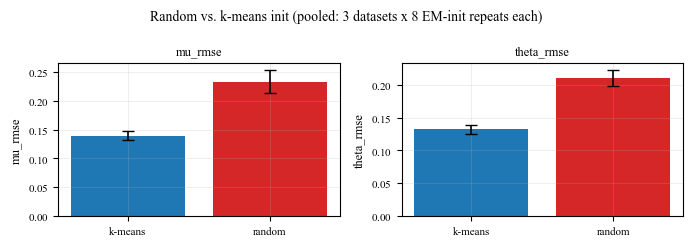

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import replace
from src.simulations.factors import SimulationCondition
from src.simulations.run import run_init_repeats

init_compare_condition = SimulationCondition(
    n_archetypes=4, n_learners=10_000, initialization="random", responses_per_learner=30,
)
rows = []
for data_seed in range(3):
    for scheme in ("random", "k-means"):
        cond = replace(init_compare_condition, initialization=scheme)
        for r in run_init_repeats(cond, data_seed=data_seed, n_repeats=8):
            rows.append({"data_seed": data_seed, "initialization": scheme, **r.metrics})
init_compare = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=figsize("acm-sigconf-text", aspect=0.35))
for ax, metric in zip(axes, ["mu_rmse", "theta_rmse"]):
    stats = init_compare.groupby("initialization")[metric].agg(["mean", "std"])
    ax.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=4, color=["#1f77b4", "#d62728"])
    ax.set_ylabel(metric)
    ax.set_title(metric)
fig.suptitle("Random vs. k-means init (pooled: 3 datasets x 8 EM-init repeats each)")
fig.tight_layout()

init_compare.groupby("initialization")[["mu_rmse", "theta_rmse"]].agg(["mean", "std"])

### 2b. Stability under repeated sampling

Assumes k-means initialization from here on (2a). With EM's own initialization draw no longer a meaningful source of variability on its own, what's left to characterize is the classical question: given the population's true archetype profiles, item difficulties, mixture weights and Q-matrix, how much does the estimate vary just from drawing a new, finite sample of learners and observed responses?

`run_sample_repeats` draws that population once (`generate_dataset`), then repeatedly redraws only the sample -- a new cohort of learners, new response outcomes, a new observed-item mask (`resample_dataset`) -- refitting with k-means initialization every time. Every recovered archetype is aligned back to the true ones independently, then plotted together (`plot_component_recovery_distribution`) to show the spread across samples: tight bundles argue the estimator is precise at this population/sample size, not merely that EM found a repeatable answer on one fixed dataset.

`q_matrix`'s self-balanced item coverage (Section 0) still matters here, for the same statistical reason as before: a skill measured by only a couple of items will show more sample-to-sample estimation noise than a well-covered one, because there is genuinely less data behind it -- not a Q-matrix construction artifact.

mean    0.131884
std     0.000709
min     0.130466
max     0.133314
dtype: float64

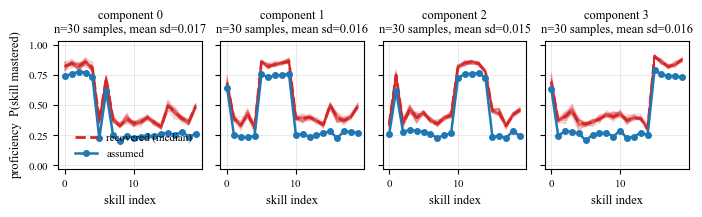

In [8]:
import pandas as pd
from src.simulations.factors import SimulationCondition
from src.simulations.run import run_sample_repeats
from src.simulations.viz import plot_component_recovery_distribution

stability_condition = SimulationCondition(
    n_archetypes=4,
    n_learners=10_000,
    initialization="k-means",
    responses_per_learner=30,
)
stability_results = run_sample_repeats(stability_condition, population_seed=0, n_repeats=30)
plot_component_recovery_distribution(
    stability_results,
    repeat_label="samples",
    figsize=figsize("acm-sigconf-text", aspect=0.32),
    save="figures/stability.pdf",
)

mu_rmse_by_repeat = pd.Series([r.metrics["mu_rmse"] for r in stability_results])
mu_rmse_by_repeat.describe()[["mean", "std", "min", "max"]]

## 3. Robustness to Data Sparsity

One-factor-at-a-time sweep over the two evidence factors named in the claim -- number of users (`n_learners`) and number of item responses per user (`responses_per_learner`) -- holding everything else at baseline. `plot_ofat_sensitivity` takes the raw per-run table from `run_design` directly (not `summarize_results`'s aggregated output, which drops the per-condition factor columns this needs) and computes the mean/std per level itself.

A full OFAT grid at higher replication counts is many fits -- this starts small (`n_replications=5`, few levels); widen before using the figure for the final write-up.

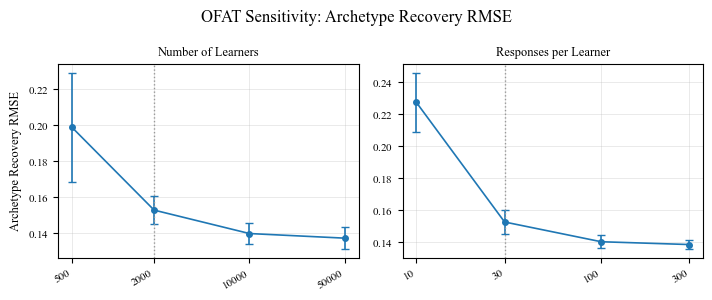

In [9]:
from src.simulations.factors import ofat_design
from src.simulations.run import run_design
from src.simulations.viz import plot_ofat_sensitivity

sparsity_factors = ["n_learners", "responses_per_learner"]
sparsity_conditions = ofat_design(factors=sparsity_factors)
sparsity_results = run_design(sparsity_conditions, n_replications=6, base_seed=0)

fig = plot_ofat_sensitivity(
    sparsity_results,
    factors=sparsity_factors,
    metric="mu_rmse",
    log_x=True,
    save="figures/sparsity.pdf",
)

**Do `n_learners` and `responses_per_learner` act through the same underlying quantity?** Both feed the same "effective observations per skill" product (`n_learners * responses_per_learner`), so `mu_rmse` should track that product regardless of the split -- but `assignment_ari` (individual cluster-assignment accuracy) depends on *per-learner* posterior precision specifically, so it shouldn't. Check with a couple of matched-product, different-split pairs.

In [10]:
from src.simulations.run import run_condition

iso_product_pairs = [
    ("many learners, few responses", dict(n_learners=8_000, responses_per_learner=15)),
    ("few learners, many responses", dict(n_learners=1_000, responses_per_learner=120)),
]
rows = []
for label, kw in iso_product_pairs:
    cond = SimulationCondition(n_archetypes=4, n_skills=20, initialization="random", **kw)
    m = run_condition(cond, seed=0)
    rows.append({"split": label, "n_learners * responses_per_learner": kw["n_learners"] * kw["responses_per_learner"],
                 "mu_rmse": m["mu_rmse"], "assignment_ari": m["assignment_ari"]})
pd.DataFrame(rows)

,split,n_learners * responses_per_learner,mu_rmse,assignment_ari
0,"many learners, few responses",120000,0.222520,0.204157
1,"few learners, many responses",120000,0.209178,0.947662


## 4. Sensitivity to the Number of Archetypes

Fit the SAME simulated data (`run_m_sweep` holds the data and train/holdout split fixed, since neither depends on `n_components_fit`) with a range of fitted archetype counts around the true one. `initialization="random"` is required here -- k-means/informed init assume the correct number of archetypes and `_initial_params` raises if they're combined with a misspecified `n_components_fit`.

`effective_n_archetypes()` -- the participation ratio of the fitted `mu` -- should saturate near the true count even once the model is handed more components than it needs, which is the payoff of the archetype-redundancy diagnostics built onto `MoLA` (`effective_n_archetypes`, `redundancy_report`).

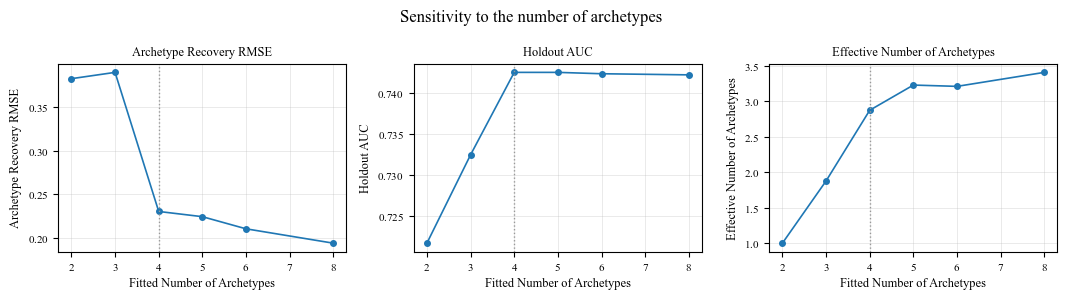

In [11]:
from src.simulations.factors import SimulationCondition
from src.simulations.run import run_m_sweep
from src.simulations.viz import plot_m_sensitivity

true_n_archetypes = 4
m_condition = SimulationCondition(n_archetypes=true_n_archetypes, n_learners=10_000)
m_results = run_m_sweep(m_condition, n_components_grid=[2, 3, 4, 5, 6, 8], seed=0)

fig = plot_m_sensitivity(
    m_results,
    true_n_archetypes=true_n_archetypes,
    metrics=("mu_rmse", "holdout_auc", "effective_n_archetypes"),
    save="figures/m_sensitivity.pdf",
)

## 5. Computational Scalability

Wall-clock fit time (`train_time_sec`, recorded by every `run_condition` call already) as problem size grows, using the same OFAT machinery as Section 3 but over the factors that plausibly drive compute cost: number of users, number of skills, and number of archetypes.

Plotted log-log (`log_x=True, log_y=True`): a power-law cost `time ~ n^p` is a straight line of slope `p` on log-log axes, so this is the honest way to read off the scaling exponent. Plotted with a linear time axis instead, genuinely linear cost (`p=1`) bends upward and can look quadratic or exponential -- a straight line under log-x/linear-y actually corresponds to *logarithmic* growth, not linear.

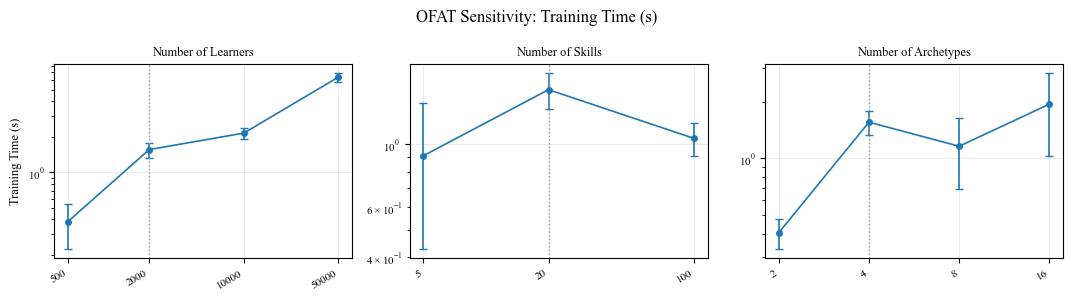

In [12]:
from src.simulations.factors import ofat_design
from src.simulations.run import run_design
from src.simulations.viz import plot_ofat_sensitivity

scalability_factors = ["n_learners", "n_skills", "n_archetypes"]
scalability_conditions = ofat_design(factors=scalability_factors)
scalability_results = run_design(scalability_conditions, n_replications=3, base_seed=0)

# log-log: a power law reads as a straight line whose slope is the exponent.
# (log_x alone, with a linear time axis, makes genuinely linear cost bend
# upward and look quadratic/exponential -- see the discussion above.)
fig = plot_ofat_sensitivity(
    scalability_results,
    factors=scalability_factors,
    metric="train_time_sec",
    log_x=True,
    log_y=True,
    save="figures/scalability.pdf",
)